## Изгиб и потеря устойчивости нелинейной консольной балки

Выполнил: Скомаровский Миша, 626 группа

**Аннотация**

Данная работа посвящена численному моделированию изгиба и анализа устойчивости упругой консольной балки в условиях больших перемещений. Исследуемая система представляет собой стержень, нагруженный силой, поведение которого описывается системой нелинейных обыкновенных дифференциальных уравнений. В модели учтены как геометрическая нелинейность, связанная с большими углами поворота сечений, так и физическая нелинейность, выраженная в зависимости изгибной жесткости от осевой деформации.

Для решения краевой задачи использован метод стрельбы, сводящий проблему к задаче Коши. Нахождение недостающих начальных условий осуществлялось с помощью итерационных методов: метода бисекции и метода секущих (аналог метода Ньютона). Проведена верификация алгоритмов путем сравнения с аналитическим решением линейной задачи при малых нагрузках.

Основной результат работы заключается в количественной оценке влияния нелинейных эффектов. Показано, что при больших нагрузках линейная теория дает существенную погрешность, тогда как нелинейная модель корректно описывает поведение системы. В задаче устойчивости обнаружено, что учет докритического сжатия снижает первую критическую силу более чем на 5% относительно классической нагрузки Эйлера.

Ключевой вывод исследования состоит в том, что доминирующим фактором, определяющим поведение тонких стержней, является геометрическая нелинейность. Влияние физической нелинейности оказалось пренебрежимо малым (менее 1% даже при больших коэффициентах нелинейности), что подтверждает гипотезу о несжимаемости оси стержня как адекватное допущение для инженерных расчетов устойчивости.

**Ключевые слова**

Изгиб балки, геометрическая нелинейность, физическая нелинейность, метод стрельбы, метод бисекции, метод Ньютона, потеря устойчивости.

**1. Введение**

История исследования механики упругих стержней и теории устойчивости насчитывает более трех столетий и тесно связана с развитием вариационного исчисления и дифференциальных уравнений. Начало научному подходу положил Роберт Гук, сформулировавший в 1660 году закон упругости, однако математическая теория изгиба начала формироваться лишь в XVIII веке. Якоб Бернулли в своих работах по изучению формы упругой линии предложил идею пропорциональности кривизны изгибающему моменту. Фундаментальный вклад внес Леонард Эйлер, который в приложении к своей работе "Метод нахождения кривых линий..." (1744) впервые решил задачу о больших прогибах упругого стержня (задача об эластике) и определил критическую силу потери устойчивости [1].

В XIX веке теория получила дальнейшее обобщение. Густав Кирхгоф в 1859 году опубликовал работу "О равновесии и движении бесконечно тонкого упругого стержня", где установил знаменитую кинетическую аналогию между уравнениями равновесия стержня и уравнениями движения твердого тела вокруг неподвижной точки [2]. Огюст Ляв в своем классическом трактате систематизировал математическую теорию упругости, включая теорию малых и конечных деформаций стержней [3]. В XX веке Степан Прокофьевич Тимошенко внес решающий вклад в прикладную теорию упругости и устойчивости упругих систем [4], рассмотрев множество задач о поведении стержней при различных нагрузках, что послужило базой для инженерных расчетов. Вопросы физической (материальной) нелинейности, при которой модуль упругости зависит от деформации, подробно исследовал Ганс Каудерер в своей монографии по нелинейной механике [5].

Параллельно с развитием теории совершенствовались численные методы решения возникающих нелинейных краевых задач, так как аналитические решения возможны лишь в редких частных случаях. Для решения краевых задач обыкновенных дифференциальных уравнений был адаптирован метод стрельбы, сводящий краевую задачу к задаче Коши; фундаментальные аспекты этого подхода и его численная реализация изложены в работах Герберта Келлера [6]. Для решения систем нелинейных алгебраических уравнений, возникающих при дискретизации, основным инструментом стал метод Ньютона-Канторовича, развитие которого описано в трудах Леонида Канторовича [7]. Особую сложность представляет численное исследование закритического поведения и точек бифуркации, где нарушается условие единственности решения. Для преодоления этой проблемы в 1970-х годах были разработаны методы продолжения по параметру длины дуги [8].

В данной работе выполнено численное моделирование изгиба и потери устойчивости консольной балки с учетом геометрической и физической нелинейности. Для решения возникающей двухточечной краевой задачи использован метод стрельбы в сочетании с итерационными алгоритмами бисекции и секущих. Проведено сравнительное исследование эффективности численных методов по скорости сходимости, а также детальный анализ влияния нелинейных эффектов на напряженно-деформированное состояние и критические нагрузки. Показано, что учет геометрической нелинейности приводит к существенному (более 5%) снижению первой критической силы по сравнению с теорией Эйлера, тогда как влияние физической нелинейности на результаты оказывается пренебрежимо малым.

**2.1 Математическая постановка задачи (изгиб балки)** 

В данной работе рассматривается 2D задача о деформировании нелинейно-упругой консольной балки. В начальном состоянии ось балки совпадает с осью X, против оси Y направлена точечная сила F с фиксированным направлением. Через s обозначим лагранжеву координату, определяющую положение каждой точки балки.

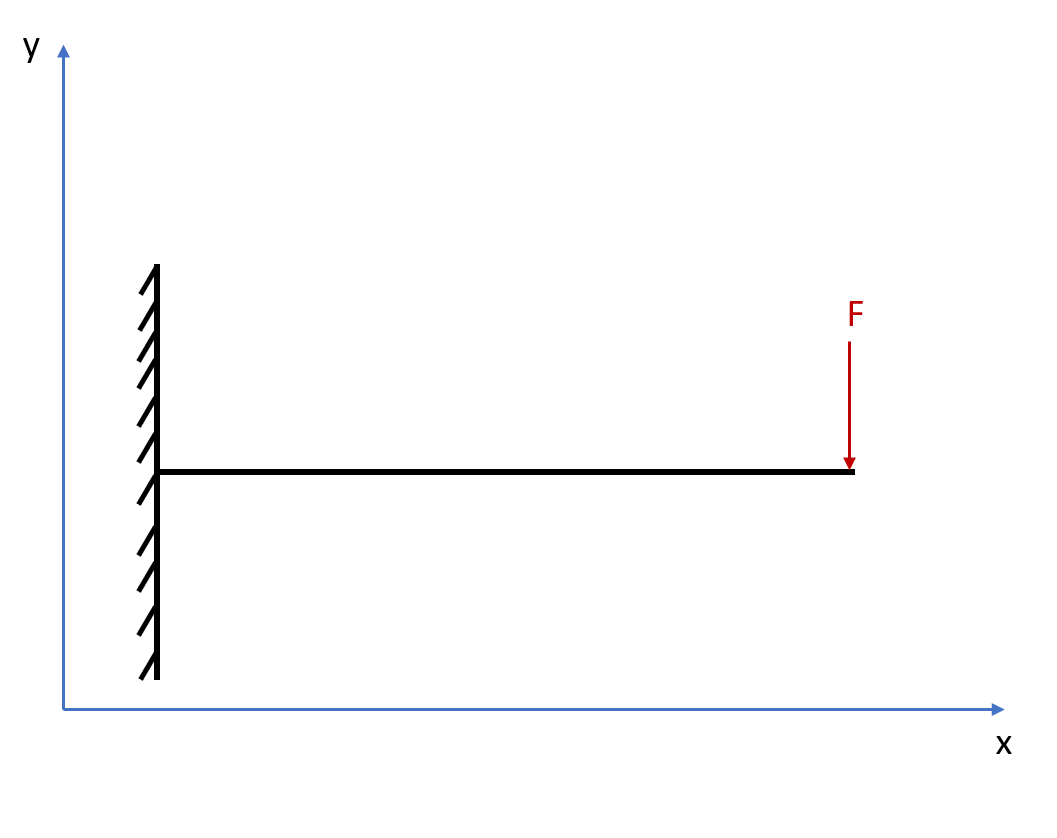

В общем виде уравнения изгиба балки имеют вид

$$
\begin{cases}
x'(s)=\left(1+\frac{F}{k_1}\sin\varphi(s)\right)\cos\varphi(s)-\frac{F}{k_2}\sin\varphi(s)\cos\varphi(s),\\
y'(s)=\left(1+\frac{F}{k_1}\sin\varphi(s)\right)\sin\varphi(s)+\frac{F}{k_2}\cos^{2}\varphi(s),\\
\varphi'(s)=\bigl(x(l)-x(s)\bigr)\frac{F}{k_3}.
\end{cases}
$$

Где $x(s), y(s)$ - декартовы координаты точки балки, $\varphi(s)$ - угол поворота сечения. $k_1 = E\cdot A, k_2=\eta\cdot G\cdot A, k_3=E\cdot I$ - жёсткости при растяжении, сдвиге и изгибе, $E$ - модуль Юнга, $G$ - модуль сдвига, $A$ - площадь поперечного сечения, $I$ - момент инерции поперечного сечения.

Упрощенная система уравнений получается в предположении о нулевой деформации сдвига. В таком случае угол поворота сечения совпадает с углом поворота касательной к деформированной оси стержня, т.е. $\frac{y'}{x'} = tg\varphi$, а уравнения принимают вид[9]

$$


\begin{cases}
x'(s)=\left(1+\dfrac{F}{k_1}\cos\varphi(s)\right)\cos\varphi(s)
+\dfrac{F}{k_2}\sin^2\varphi(s),\\
y'(s)=\left(1+\dfrac{F}{k_1}\cos\varphi(s)\right)\sin\varphi(s)
-\dfrac{F}{k_2}\sin\varphi(s)\cos\varphi(s),\\
\varphi'(s)=\dfrac{F}{k_3}\,\bigl[x(l)-x(s)\bigr].
\end{cases}

$$

Будем рассматривать случай, когда жёсткость на изгиб будет зависеть от деформации, т.е. $EI = EI_0(1+k\cdot\varepsilon)$ , $\varepsilon = \frac{dl}{ds} - 1$ - относительное удлинение балки. Граничные условия в этой задаче имеют вид:
$$
x(0) = 0, y(0) = 0, \varphi(0) = 0, \varphi'(L) = 0
$$

Продифференцировав последнее уравнение в системе по s c учётом того, что $\frac{dl}{ds} = \sqrt{x'(s)^2+y'(s)^2} = 1 + \frac{F}{k1}\sin\varphi(s)$, мы получим краевую задачу для нелинейного ОДУ 2-го порядка:


$$
\boxed{

\displaystyle
\varphi''(s)
+\frac{k\,\frac{F}{k_1}\cos\varphi(s)}{1+k\,\frac{F}{k_1}\sin\varphi(s)}\,
\bigl(\varphi'(s)\bigr)^2
+\frac{F}{E I_0}\,
\frac{\left(1+\frac{F}{k_1}\sin\varphi(s)\right)\cos\varphi(s)}
{1+k\,\frac{F}{k_1}\sin\varphi(s)}
=0, \quad s\in[0,L],\
\quad \varphi(0)=0,\quad \varphi'(L)=0.

}
$$


**2.2 Математическая постановка задачи (потеря устойчивости)** 

Вторая постановка, рассмотренная в данной работе - задача о потере устойчивости. Теперь сила F будет направлена против оси X.

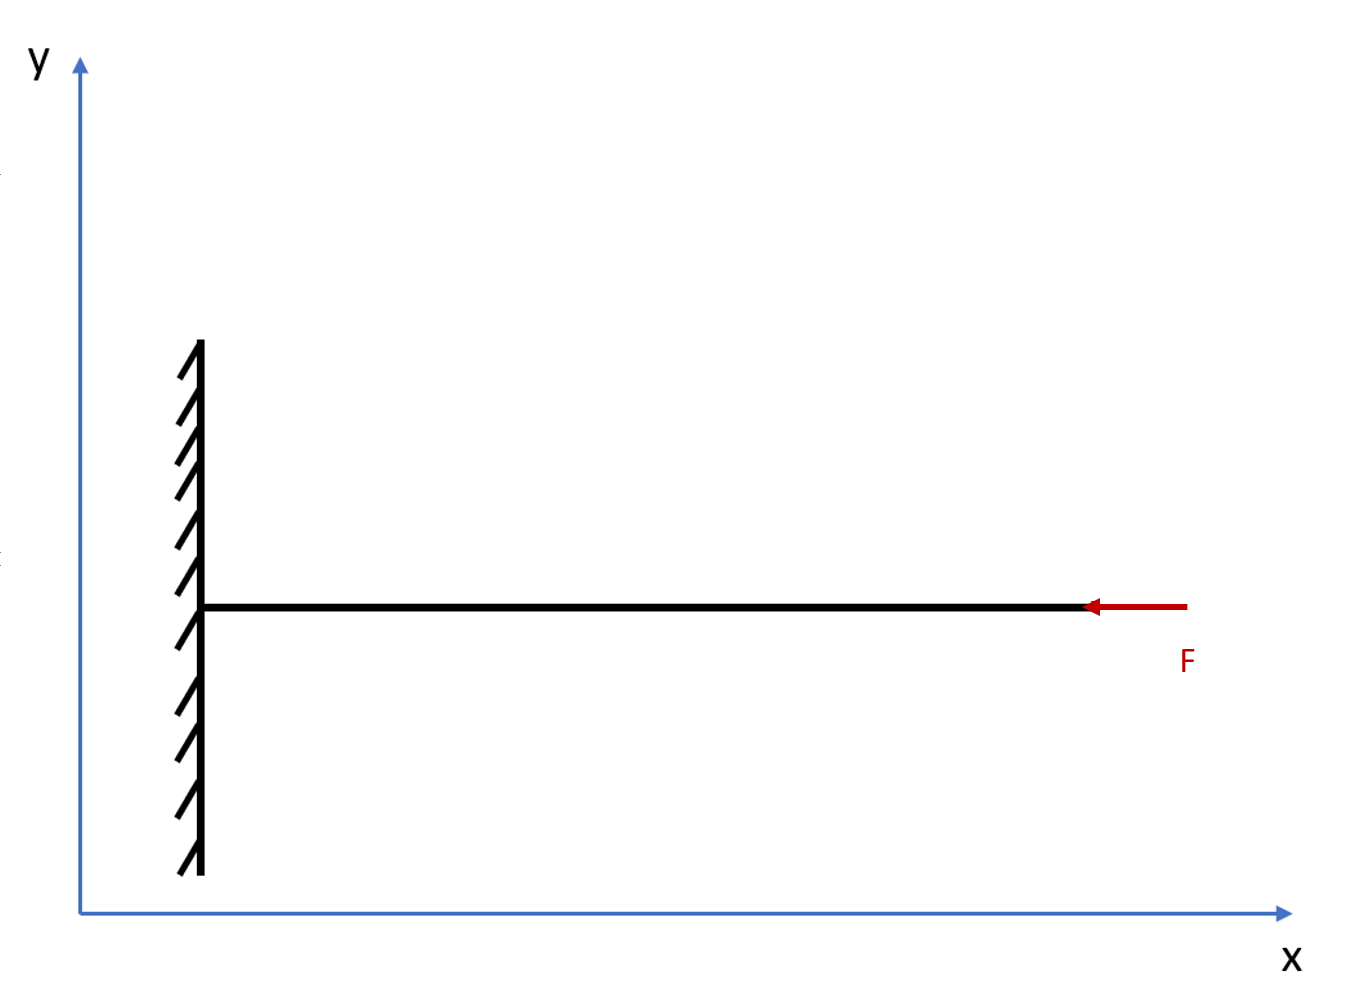

Аналогичным 1-ой постановке образом можно из уравнений равновесия получить одно нелинейное ОДУ 2-го порядка:
$$
\boxed{

\displaystyle
\varphi''(s)
-\frac{k\,\frac{F}{k_1}\sin\varphi(s)}{1+k\,\frac{F}{k_1}\cos\varphi(s)}\,
\bigl(\varphi'(s)\bigr)^2
-\frac{F}{E I_0}\,
\frac{\left(1+\frac{F}{k_1}\cos\varphi(s)\right)\sin\varphi(s)}
{1+k\,\frac{F}{k_1}\cos\varphi(s)}
=0, \quad s\in[0,L],\
\quad \varphi(0)=0,\quad \varphi'(L)=0.

}
$$
У этого уравнения при любом значении нагрузки $F$ есть тривиальное решение $\phi(s)\equiv 0$. Оно соответствует случаю, когда балка просто сжимается по оси X. Начиная с какого-то уровня нагрузки $F_{cr}$, решение перестаёт быть единственным. Физически это означает потерю устойчивости балки: при малом отклонении начальных условий на левом конце балки, например $\phi'(s) = \alpha > 0$, конструкция значительно отклоняется от тривиального решения и случайным образом принимает одну из возможных при данном уровне нагрузки собственных форм.

**3.1 Численное решение (изгиб балки)**

Поставленная дифференциальная задача краевая и нелинейная, следовательно напрямую её решить с помощью конечных разностей нельзя. Поэтому мы будем её решать с помощью разновидностей метода стрельбы, сводящих решение одной краевой задачи к последовательности задач Коши. 

Пусть имеется нелинейное ОДУ 2-го порядка:
$$y''(x) = f(x, y, y'), \quad x \in [0, L]$$
С краевыми условиями
$$y(0) = 0,\quad y'(L) = 0$$
Введём параметр $\alpha$, отвечающий за угол наклона в начальной точке $y'(0) = \alpha$ и будем подбирать такое значение параметра, при котором решение полученной задачи Коши $y_{\alpha}(x)$ будет принимать необходимое значение $y'_{\alpha}(L) = 0$. Фактически, мы получаем одномерное нелинейное алгебраическое уравнение $r(\alpha) = 0$, где $r(\alpha) = y'_{\alpha}(L)$ и можем воспользоваться численными методами решения данного типа уравнений. Далее будут рассмотрены два основных метода решения нелинейных алгебраических уравнений: метод бисекции и метод Ньютона.

**•** *Метод бисекции*

Метод бисекции, он же метод деления отрезка пополам заключается в следующем: сначала находится отрезок $[\alpha_0,\alpha_1]$, такой что $r(\alpha_0)\cdot r(\alpha_1)<0$. По теореме о промежуточных значениях, это означает, что на отрезке функция обращается в 0. Далее берётся середина отрезка $\alpha_M=\frac{\alpha_0+\alpha_1}{2}$ и в зависимости от того, где теперь функция меняет знак, берётся либо отрезок $[\alpha_0, \alpha_M]$, либо $[\alpha_M, \alpha_1]$ и те же действия повторяются для него. Так продолжается до тех пор, пока длина отрезка не станет меньше необходимой точности решения.
Проблемным здесь является поиск интервала, на котором функция меняет знак. Обычно берётся некоторый начальный отрезок и увеличивается до тех пор, пока функция не станет менять знак на его концах.

**•** *Метод Ньютона*

Метод Ньютона основывается на разложении функции в ряд Тейлора для поиска нового приближения. Пусть имеется некоторое приближение решения на $n$-ом шаге $\alpha_n$, тогда
$$r(\alpha_{n+1}) \approx r(\alpha_n) + r'(\alpha_n)(\alpha_{n+1} - \alpha_n) = 0$$
Значит новое приближение ищется как
$$\alpha_{n+1} = \alpha_n - \frac{r(\alpha_n)}{r'(\alpha_n)}$$
В случае, если невозможно или трудоёмко вычисление производной функции, она заменяется разностным выражением:
$$\alpha_{n+1} = \alpha_n - \frac{r(\alpha_n) \cdot 2h}{r(\alpha_n + h)-r(\alpha_n - h)}$$
Данный метод носит название метода секущих и при хорошем выборе начального приближения обладает сверхлинейной сходимостью.
Итерации обрываются, когда выполнено одно из двух условий:
$$|r(\alpha_{n+1})| < \varepsilon, \quad |\alpha_{n+1}-\alpha_n|<\varepsilon$$

**•** *Решение задачи Коши*

При каждом фиксированном $\alpha$ мы имеем задачу Коши
$$y''(x) = f(x, y, y'), \quad x \in [0, L]$$
$$y(0) = 0,\quad y'(0) = \alpha$$
и её можно решать обычными конечно-разностными методами, например методом Рунге-Кутты 4-го порядка:

$$

\begin{cases}
y' = v,\\
v' = f(y,v,x).
\end{cases}
\qquad
x_{n+1}=x_n+h.

$$
$$
\begin{aligned}
k_1 &= h\,v_n,\\
\ell_1 &= h\,f(y_n,v_n,x_n),\\
k_2 &= h\left(v_n+\frac{\ell_1}{2}\right),\\
\ell_2 &= h\,f\!\left(y_n+\frac{k_1}{2},\,v_n+\frac{\ell_1}{2},\,x_n+\frac{h}{2}\right),\\
k_3 &= h\left(v_n+\frac{\ell_2}{2}\right),\\
\ell_3 &= h\,f\!\left(y_n+\frac{k_2}{2},\,v_n+\frac{\ell_2}{2},\,x_n+\frac{h}{2}\right),\\
k_4 &= h\left(v_n+\ell_3\right),\\
\ell_4 &= h\,f\!\left(y_n+k_3,\,v_n+\ell_3,\,x_n+h\right),
\end{aligned}
$$

$$

\begin{aligned}
y_{n+1} &= y_n+\frac{1}{6}\left(k_1+2k_2+2k_3+k_4\right),\\
v_{n+1} &= v_n+\frac{1}{6}\left(\ell_1+2\ell_2+2\ell_3+\ell_4\right).
\end{aligned}

$$

Задача Коши об изгибе балки решается с помощью данного куска кода:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Solve second-order ODE for phi - with stiffness variation
def solve_phi_equation(phi_prime_0, EI0, k1, k, L, F):
    """
    Solve the second-order differential equation with stiffness variation:
    φ''(s) + [k·F/k1·cos(φ)] / [1 + k·F/k1·sin(φ)] · (φ'(s))² + 
           [F/(EI0)] · [(1 + F/k1·sin(φ))·cos(φ)] / [1 + k·F/k1·sin(φ)] = 0
    
    where:
    - EI = EI0·(1 + k·ε), ε = dl/ds - 1 (relative elongation)
    - dl/ds = sqrt(x'²+ y'²) = 1 + F/k1·sin(φ)
    """
    
    # Convert to first-order system: [phi, phi']
    sol_0 = np.array((0.0, phi_prime_0), dtype=np.float64)
    
    s_0 = 0.0
    s_1 = L
    N = 300
    h = (s_1 - s_0) / N
    s = np.linspace(s_0, s_1, N + 1)
    
    sol = np.zeros((N + 1, 2), dtype=np.float64)
    sol[0] = sol_0
    
    def f(state, s_i):
        phi = state[0]
        dphi_ds = state[1]
        
        # Calculate strain-dependent terms
        sin_phi = np.sin(phi)
        cos_phi = np.cos(phi)
        
        # ε = F/k1·sin(φ) (from dl/ds = 1 + F/k1·sin(φ))
        epsilon = F / k1 * sin_phi
        
        # Denominator: 1 + k·F/k1·sin(φ) = 1 + k·ε
        denom = 1.0 + k * epsilon
        
        # Avoid division by zero
        if abs(denom) < 1e-12:
            denom = 1e-12 * np.sign(denom) if denom != 0 else 1e-12
        
        # From the equation: φ'' + [k·F/k1·cos(φ)/(1+k·ε)]·(φ')² + [F/(EI0)]·[(1+F/k1·sin(φ))·cos(φ)/(1+k·ε)] = 0
        term1 = (k * F / k1 * cos_phi / denom) * dphi_ds**2
        term2 = (F / EI0) * ((1.0 + F / k1 * sin_phi) * cos_phi / denom)
        
        dphi_prime_ds = term1 + term2
        
        return np.array((dphi_ds, dphi_prime_ds))
    
    # RK4 integration
    for i in range(N):
        s_i = s[i]
        d1 = h * f(sol[i], s_i)
        d2 = h * f(sol[i] + d1/2.0, s_i + h/2.0)
        d3 = h * f(sol[i] + d2/2.0, s_i + h/2.0)
        d4 = h * f(sol[i] + d3, s_i + h)
        sol[i+1] = sol[i] + (d1 + 2.0*d2 + 2.0*d3 + d4) / 6.0
    
    return s, sol

Для изгиба балки вниз начальное $\phi'(0)$ отрицательное, поэтому в качестве отрезка для метода бисекции берётся $[-2\sqrt{\omega\cdot L}, 0]$, нижняя грань является аналитическим углом наклона для линейной задачи. В случае, если отрезок не содержит корня, нижняя грань удваивается. Код, реализующий метод стрельбы с бисекцией представлен ниже:

Декартовы координаты получаются непосредственным интегрированием по $s$ для вычисленной функции $\phi(s)$. Код приведён ниже:

In [ ]:
# Reconstruct x(s) and y(s) from phi(s) solution
def reconstruct_coordinates(s, phi_sol, k1, F):
    """
    Given phi(s), integrate to get x(s) and y(s):
    x'(s) = (1 + F/k1·cos(φ))·cos(φ)
    y'(s) = (1 + F/k1·cos(φ))·sin(φ)
    """
    N = len(s)
    x = np.zeros(N)
    y = np.zeros(N)
    
    for i in range(1, N):
        ds = s[i] - s[i-1]
        phi_avg = (phi_sol[i] + phi_sol[i-1]) / 2.0
        
        # Strain-dependent elongation factor: dl/ds = 1 + F/k1·cos(φ)
        elongation_factor = 1.0 + F / k1 * np.cos(phi_avg)
        
        x[i] = x[i-1] + ds * elongation_factor * np.cos(phi_avg)
        y[i] = y[i-1] + ds * elongation_factor * np.sin(phi_avg)
    
    return x, y

In [ ]:
# Bisection method (shooting) to find phi'(0) such that phi'(L) = 0
def shooting_method_bisection(EI0, k1, k, L, F):
    """
    Boundary value problem:
    φ(0) = 0, φ'(L) = 0
    
    Find φ'(0) using shooting method with bisection
    """
    
    print("\n=== Strain-Dependent Stiffness - Shooting Method (Bisection) ===")
    print(f"Boundary conditions: φ(0) = 0, φ'(L) = 0")
    print("Finding φ'(0) using bisection method...")
    
    # Initial bracket for phi'(0)
    # For downward force, phi should decrease (negative), so phi'(0) < 0
    omega = F / EI0
    alpha_low = -2.0 * np.sqrt(omega * L)  # More negative
    alpha_high = 0.0  # Zero or slightly positive
    
    max_iter = 100
    tolerance = 1e-10
    
    iterations_data = []
    
    # Evaluate boundary condition at bracket endpoints
    s, sol_low = solve_phi_equation(alpha_low, EI0, k1, k, L, F)
    f_low = sol_low[-1, 1]
    
    s, sol_high = solve_phi_equation(alpha_high, EI0, k1, k, L, F)
    f_high = sol_high[-1, 1]
    
    print(f"Initial bracket: α ∈ [{alpha_low:.6e}, {alpha_high:.6e}]")
    print(f"f(α_low) = {f_low:.6e}, f(α_high) = {f_high:.6e}")
    
    # Check if bracket is valid
    if f_low * f_high > 0:
        print("WARNING: Initial bracket does not contain root. Adjusting...")
        if f_low > 0 and f_high > 0:
            alpha_low *= 2.0
            s, sol_high = solve_phi_equation(alpha_high, EI0, k1, k, L, F)
            f_high = sol_high[-1, 1]
        print(f"Adjusted bracket: α ∈ [{alpha_low:.6e}, {alpha_high:.6e}]")
        print(f"f(α_low) = {f_low:.6e}, f(α_high) = {f_high:.6e}")
    
    for iter_count in range(max_iter):
        alpha_mid = (alpha_low + alpha_high) / 2.0
        
        s, sol_mid = solve_phi_equation(alpha_mid, EI0, k1, k, L, F)
        f_mid = sol_mid[-1, 1]
        
        iterations_data.append({
            'iteration': iter_count,
            'phi_prime_0': alpha_mid,
            'phi_solution': sol_mid[:, 0],
            'error': abs(f_mid),
            'bracket_width': alpha_high - alpha_low
        })
        
        if iter_count % 5 == 0:
            print(f"Iter {iter_count:3d}: α = {alpha_mid:12.6e}, "
                  f"f(α) = {f_mid:12.6e}, bracket = {alpha_high - alpha_low:12.6e}")
        
        if abs(f_mid) < tolerance or (alpha_high - alpha_low) < tolerance:
            break
        
        if f_low * f_mid < 0:
            alpha_high = alpha_mid
            f_high = f_mid
        else:
            alpha_low = alpha_mid
            f_low = f_mid
    
    print(f"\nConverged in {iter_count+1} iterations")
    print(f"Final φ'(0) = {alpha_mid:.6e}")
    print(f"φ'(L) = {sol_mid[-1, 1]:.6e} (should be ~0)")
    print(f"φ(L) = {np.degrees(sol_mid[-1, 0]):.3f}°")
    
    # Reconstruct coordinates
    x, y = reconstruct_coordinates(s, sol_mid[:, 0], k1, F)
    
    return iterations_data, s, sol_mid, x, y

В качестве начального приближения метода Ньютона также берётся аналитический угол для линейной задачи. Код, реализующий метод стрельбы с Ньютоном, представлен ниже:

In [ ]:
# Newton's method (shooting) to find phi'(0) such that phi'(L) = 0
def shooting_method_newton(EI0, k1, k, L, F):
    """
    Boundary value problem:
    φ(0) = 0, φ'(L) = 0
    
    Find φ'(0) using shooting method with Newton's method
    """
    
    print("\n=== Strain-Dependent Stiffness - Shooting Method (Newton) ===")
    print(f"Boundary conditions: φ(0) = 0, φ'(L) = 0")
    print("Finding φ'(0) using Newton's method...")
    
    # Initial guess for phi'(0)
    # For downward bending, phi decreases initially, so phi'(0) should be negative
    omega = F / EI0
    _, _, phi_sol_bisection, _, _ = shooting_method_bisection(EI0, k1, k, L, F)
    phi_prime_0 = -4.0/3.0*np.sqrt(omega * L)
    h_alpha = 1e-6
    
    max_iter = 50
    tolerance = 1e-10
    
    iterations_data = []
    
    for iter_count in range(max_iter):
        # Solve with current guess
        s, sol_m = solve_phi_equation(phi_prime_0 - h_alpha, EI0, k1, k, L, F)
        s, sol_0 = solve_phi_equation(phi_prime_0, EI0, k1, k, L, F)
        s, sol_p = solve_phi_equation(phi_prime_0 + h_alpha, EI0, k1, k, L, F)
        
        # Boundary condition error: φ'(L) should be 0
        f_m = sol_m[-1, 1]
        f_0 = sol_0[-1, 1]
        f_p = sol_p[-1, 1]
        
        # Numerical derivative
        df_dphi_prime_0 = (f_p - f_m) / (2.0 * h_alpha)
        
        # Newton step
        delta = -f_0 / df_dphi_prime_0
        phi_prime_0 = phi_prime_0 + delta
        
        iterations_data.append({
            'iteration': iter_count,
            'phi_prime_0': phi_prime_0,
            'phi_solution': sol_0[:, 0],
            'error': abs(f_0)
        })
        
        if iter_count % 5 == 0:
            print(f"Iter {iter_count:3d}: φ'(0) = {phi_prime_0:12.6e}, error |φ'(L)| = {abs(f_0):12.6e}")
        
        if abs(f_0) < tolerance or abs(delta) < tolerance:
            break
    
    print(f"\nConverged in {iter_count+1} iterations")
    print(f"Final φ'(0) = {phi_prime_0:.6e}")
    print(f"φ'(L) = {sol_0[-1, 1]:.6e} (should be ~0)")
    print(f"φ(L) = {np.degrees(sol_0[-1, 0]):.3f}°")
    
    # Reconstruct coordinates
    x, y = reconstruct_coordinates(s, sol_0[:, 0], k1, F)
    
    return iterations_data, s, sol_0, x, y

Для сравнения, приведём также аналитическое решение для линейного-упругого стержня в малых деформациях:

In [ ]:
# Linear theory for comparison
def solve_linear_theory(EJ, L, F, verbose=True):
    """
    Linear theory: cantilever with free end
    φ(0) = 0, φ'(L) = 0 => M(L) = 0
    
    For vertical force at free end:
    M(x) = -F·(L-x)
    φ'(x) = M(x)/EJ = -F·(L-x)/EJ
    φ(x) = -F·(L·x - x²/2)/EJ
    w'(x) = φ(x)
    w(x) = -F·(L·x²/2 - x³/6)/EJ
    """
    
    N = 300
    x = np.linspace(0, L, N+1)
    
    phi = -F * (L * x - x**2 / 2.0) / EJ
    w = -F * (L * x**2 / 2.0 - x**3 / 6.0) / EJ
    
    if verbose:
        print("\n=== Linear Theory ===")
        print(f"End deflection: w(L) = {w[-1]*1000:.3f} mm")
        print(f"End rotation: φ(L) = {np.degrees(phi[-1]):.3f}°")
    
    return x, w, phi

**3.2 Численное решение (потеря устойчивости)**

Займёмся теперь задачей поиска критических нагрузок и собственных форм. Имеется всё та же нелинейная краевая задача
$$y''(x) = f(x, y, y'), \quad x \in [0, L]$$
С краевыми условиями
$$y(0) = 0,\quad y'(L) = 0$$
Однако теперь известно, что у задачи имеется тривиальное решение $y(x)\equiv 0$. Попытки подобрать задачу Коши, соответствующую краевым условиям, будут неизбежно приводить к этому тривиальному решению. Поскольку мы хотим найти нетривиальные собственные формы, потребуем выполнение начальных условий:
$$y(0)=0, y'(0) = 1.0$$
Конкретное значение производной не имеет значения, т.к. отвечает лишь за множитель масштаба сосбственной формы.
Введём параметр нагрузки $\lambda$ и будем рассматривать семейство диф. уравнений:
$$y''(x) = f(x, y, y', \lambda), \quad x \in [0, L]$$
$$y(0)=0, y'(0) = 1.0$$
И теперь мы будем подбирать такие значения нагрузки $\lambda_{cr}$, при которых будут выполнены условия краевой задачи. Это называется методом продолжения по параметру. Таким образом, нужно чтобы решение задачи Коши при заданной нагрузке $y_{\lambda_{cr}}$ было таким, что $r(\lambda_{cr}) = y'_{\lambda_{cr}}(L) = 0$. Получается нелинейное алгебраическое уравнение, которое можно решить описанными выше методами бисекции и Ньютона.

Конкретно для задачи сжатия балки, в качестве параметра нагрузки естественно взять точечную силу $F$. В качестве начального приближения для каждой критической нагрузкии разумно взять собственные значения линеаризованной задачи:
$$\phi''(s) = \frac{F}{EI_0}(1+\frac{F}{k_1})\phi(s)$$
Её собственные значения:
$$\lambda_n = -\frac{F_n}{EI_0}(1+\frac{F_n}{k_1}) = \frac{\pi^2 n^2}{L^2}$$
Получается квадратное уравнение на $F_n$, которое можно решить аналитически, или, если совсем лень, численно.


Код, решающий задачу Коши для задачи сжатия балки с заданной нагрузкой, представлен ниже:

In [ ]:
# Solve second-order ODE for phi - with stiffness variation
def solve_phi_equation_buckling(phi_prime_0, EI0, k1, k, L, F):
    """
    Solve the second-order differential equation with stiffness variation:
    φ''(s) - [k·F/k1·sin(φ)] / [1 + k·F/k1·cos(φ)] · (φ'(s))² - 
           [F/(EI0)] · [(1 + F/k1·cos(φ))·sin(φ)] / [1 + k·F/k1·cos(φ)] = 0
    
    where:
    - EI = EI0·(1 + k·ε), ε = dl/ds - 1 (relative elongation)
    - dl/ds = sqrt(x'²+ y'²) = 1 + F/k1·cos(φ)
    """
    
    # Convert to first-order system: [phi, phi']
    sol_0 = np.array((0.0, phi_prime_0), dtype=np.float64)
    
    s_0 = 0.0
    s_1 = L
    N = 300
    h = (s_1 - s_0) / N
    s = np.linspace(s_0, s_1, N + 1)
    
    sol = np.zeros((N + 1, 2), dtype=np.float64)
    sol[0] = sol_0
    
    def f(state, s_i):
        phi = state[0]
        dphi_ds = state[1]
        
        # Calculate strain-dependent terms
        sin_phi = np.sin(phi)
        cos_phi = np.cos(phi)
        
        # Denominator: 1 + k·F/k1·cos(φ)
        denom = 1.0 + k * F / k1 * cos_phi
        
        # Avoid division by zero
        if abs(denom) < 1e-12:
            denom = 1e-12 * np.sign(denom) if denom != 0 else 1e-12
        
        # From the equation in the image:
        # φ'' - [k·F/k1·sin(φ)/(1+k·F/k1·cos(φ))]·(φ')² - [F/(EI0)]·[(1+F/k1·cos(φ))·sin(φ)/(1+k·F/k1·cos(φ))] = 0
        term1 = -(k * F / k1 * sin_phi / denom) * dphi_ds**2
        term2 = -(F / EI0) * ((1.0 + F / k1 * cos_phi) * sin_phi / denom)
        
        dphi_prime_ds = term1 + term2
        
        return np.array((dphi_ds, dphi_prime_ds))
    
    # RK4 integration
    for i in range(N):
        s_i = s[i]
        d1 = h * f(sol[i], s_i)
        d2 = h * f(sol[i] + d1/2.0, s_i + h/2.0)
        d3 = h * f(sol[i] + d2/2.0, s_i + h/2.0)
        d4 = h * f(sol[i] + d3, s_i + h)
        sol[i+1] = sol[i] + (d1 + 2.0*d2 + 2.0*d3 + d4) / 6.0
    
    return s, sol

Код для нахождения критических нагрузок и соответствующих собственных форм представлен ниже:

In [ ]:
# Find eigenvalue (critical load F) using Newton's method for eigenvalue problem
def find_buckling_load_newton(EI0, k1, k, L, F_guess, mode_index):
    """
    Eigenvalue problem:
    φ(0) = 0, φ'(0) = 1, φ'(L) = 0
    
    Find critical load F such that the boundary condition φ'(L) = 0 is satisfied
    using Newton's method
    """
    
    print("=" * 30)
    print(f'Start shooting method to find buckling mode {mode_index}')
    
    phi_prime_0 = -1.0  # Fixed initial slope
    F = F_guess
    h_F = 0.01  # Step for numerical derivative w.r.t. F
    
    max_iter = 1000
    tolerance = 1e-4
    
    for iter_count in range(max_iter):
        print(f'Iteration = {iter_count}, Current F = {F:.6f}')
        
        # Solve with perturbed F values
        s, sol_p = solve_phi_equation_buckling(phi_prime_0, EI0, k1, k, L, F + h_F)
        s, sol_m = solve_phi_equation_buckling(phi_prime_0, EI0, k1, k, L, F - h_F)
        s, sol_0 = solve_phi_equation_buckling(phi_prime_0, EI0, k1, k, L, F)
        
        # Boundary condition error: φ'(L) should be 0
        f_p = sol_p[-1, 1]
        f_m = sol_m[-1, 1]
        f_0 = sol_0[-1, 1]
        
        # Numerical derivative df/dF
        df_dF = (f_p - f_m) / (2.0 * h_F)
        
        # Newton step
        F = F - f_0 / df_dF
        
        if np.abs(f_0) < tolerance:
            print(f"Converged! Critical load F = {F:.6f}")
            break
    
    print("=" * 30)
    
    return F, sol_0

# Find multiple buckling modes
def get_buckling_modes(n_modes, EI0, k1, k, L, F_range=250.0):
    """
    Find multiple buckling modes and corresponding critical loads.
    Uses linearized solution as initial guess: F_n ~ (n*π/L)²·EI0/(1+F/k1)
    """
    
    print("\n=== Finding Buckling Modes ===")
    
    # For linear problem: φ''(s) - λ·φ(s) = 0 with φ(0)=0, φ'(0)=1, φ'(L)=0
    # Solution: φ = (1/√λ)·sin(√λ·s), boundary condition gives: cos(√λ·L) = 0
    # Therefore: √λ·L = π/2 + n·π, λ_n = ((2n+1)·π/(2L))²
    # For our problem: λ = F/(EI0)·(1+F/k1), simplified: λ ≈ F/EI0 for initial guess
    # So F_n ≈ EI0·((2n+1)·π/(2L))²
    
    critical_loads = []
    eigenmodes = []
    
    # Create a search grid to find sign changes
    n_points = 100
    F_grid = np.linspace(0.1, F_range, n_points)
    
    # Calculate boundary residuals for all grid points
    residuals = np.zeros(n_points)
    phi_prime_0 = 1.0
    
    print("\nScanning for eigenvalues...")
    for i, F_val in enumerate(F_grid):
        try:
            s, sol = solve_phi_equation_buckling(phi_prime_0, EI0, k1, k, L, F_val)
            residuals[i] = sol[-1, 1]  # φ'(L)
        except:
            residuals[i] = np.nan
    
    # Find sign changes (indicating eigenvalues)
    sign_changes = []
    for i in range(len(residuals) - 1):
        if not np.isnan(residuals[i]) and not np.isnan(residuals[i + 1]):
            if residuals[i] * residuals[i + 1] < 0:
                sign_changes.append((F_grid[i], F_grid[i + 1]))
    
    print(f"\nFound {len(sign_changes)} potential eigenvalues")
    
    for n, (F_low, F_high) in enumerate(sign_changes):
        if n >= n_modes:
            break
        
        # Use midpoint as initial guess
        F_guess = (F_low + F_high) / 2.0
        
        print(f"\nSearching for mode {n} in interval [{F_low:.3f}, {F_high:.3f}], initial guess F = {F_guess:.3f}")
        
        try:
            F_critical, mode_solution = find_buckling_load_newton(EI0, k1, k, L, F_guess, n)
            critical_loads.append(F_critical)
            eigenmodes.append(mode_solution)
        except Exception as e:
            print(f"Failed to find mode {n}: {e}")
            break
    
    return np.array(critical_loads), eigenmodes

**4.1 Результаты решения задачи об изгибе балки и визуализация** 

Зададим параметры задачи:

In [ ]:
# Material and geometric properties
E = 2.0e11   # Young's modulus (Pa)
b = 0.02    # Width (m)
h = 0.005   # Height (m) 
I = (b * h**3) / 12  # Moment of inertia
EI0 = E * I  # Initial bending stiffness

# Stiffness parameters
k = 0.2  # Stiffness variation coefficient (EI = EI0*(1 + k*ε))

# Axial stiffness
A = b * h  # Cross-sectional area
k1 = E * A  # Axial stiffness EA

L = 1.0     # Length (m)

F = 300.0

Посчитаем результаты для данной нагрузки:

In [ ]:
print(f"\n=== Running single load case with F = {F:.3f} N ===")
print(f"\nBoundary conditions: x(0) = 0, y(0) = 0, φ(0) = 0, φ'(L) = 0")

# Linear theory (for comparison, using initial stiffness)
x_linear, w_linear, phi_linear = solve_linear_theory(EI0, L, F)

# Nonlinear theory - Shooting method (Newton)
iterations_newton, s_newton, phi_sol_newton, x_newton, y_newton = shooting_method_newton(EI0, k1, k, L, F)

# Nonlinear theory - Shooting method (Bisection)
iterations_bisection, s_bisection, phi_sol_bisection, x_bisection, y_bisection = shooting_method_bisection(EI0, k1, k, L, F)

Теперь вычислим зависимость прогиба в правом конце балки от нагрузки в нелинейном случае:

In [ ]:
print("\n=== Computing Load-Deflection Curves ===")
F_values = np.linspace(5, 250, 20)
deflections_linear = []
deflections_newton = []
deflections_bisection = []

for F_test in F_values:
    print(f"Computing for F = {F_test:.1f} N...", end='\r')
    
    # Linear theory (suppress output)
    x_lin, w_lin, phi_lin = solve_linear_theory(EI0, L, F_test, verbose=False)
    deflections_linear.append(abs(w_lin[-1]) * 1000)
    
    # Newton method (suppress output)
    try:
        import sys
        from io import StringIO
        old_stdout = sys.stdout
        sys.stdout = StringIO()
        
        _, _, _, _, y_newt = shooting_method_newton(EI0, k1, k, L, F_test)
        deflections_newton.append(abs(y_newt[-1]) * 1000)
        
        _, _, _, _, y_bisect = shooting_method_bisection(EI0, k1, k, L, F_test)
        deflections_bisection.append(abs(y_bisect[-1]) * 1000)
        
        sys.stdout = old_stdout
    except:
        sys.stdout = old_stdout
        deflections_newton.append(np.nan)
        deflections_bisection.append(np.nan)


print(f"\nLoad-deflection curves computed for {len(F_values)} load cases.")

Код для визуализации полученных результатов представлен ниже:

In [ ]:
def plot_bending_results(L, F, x_linear, w_linear, phi_linear, 
                         iterations_newton, s_newton, phi_sol_newton, x_newton, y_newton,
                         iterations_bisection, s_bisection, phi_sol_bisection, x_bisection, y_bisection,
                         F_values=None, deflections_linear=None, deflections_newton=None, deflections_bisection=None):
    """
    Plot results for regular bending analysis
    """
    # Plotting
    fig = plt.figure(figsize=(20, 5))
    fig.suptitle(f'Bending Analysis Results (F = {F:.1f} N)', fontsize=16, fontweight='bold')
    
    # Plot 1: Deformed beam shape
    ax1 = plt.subplot(1, 4, 1)
    
    # Fixed support
    support_height = max(abs(w_linear[-1]), abs(y_newton[-1])) * 1000 * 0.15
    ax1.plot([0, 0], [-support_height, support_height], 'k-', linewidth=4)
    ax1.plot([-5, -5], [-support_height*0.8, support_height*0.8], 'k-', linewidth=2)
    
    # Undeformed beam
    ax1.plot([0, L*1000], [0, 0], 'k--', alpha=0.5, linewidth=1, label='Undeformed')
    
    # Force arrow at undeformed end
    arrow_length = max(30, abs(y_newton[-1])*1000*0.15)
    ax1.arrow(L*1000, 0, 0, arrow_length,
             head_width=10, head_length=10, fc='red', ec='red', linewidth=2, alpha=0.8)
    ax1.text(L*1000 - 500, arrow_length/10 - 100, f'F = {F} N',
             fontsize=9, color='red', va='center')
    
    # Deformed shapes
    ax1.plot(x_linear*1000, -w_linear*1000, 'b-', linewidth=2.5, label='Linear theory')
    ax1.plot(x_newton*1000, -y_newton*1000, 'r-', linewidth=2.5, label='Newton (strain-dep.)')
    ax1.plot(x_bisection*1000, -y_bisection*1000, 'g--', linewidth=2, label='Bisection (strain-dep.)')
    
    ax1.set_xlabel('x [mm]')
    ax1.set_ylabel('y [mm]')
    ax1.set_title('Deformed Beam Shape')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='lower left')
    ax1.axis('equal')
    ax1.invert_yaxis()
    
    errors_newton = [data['error'] for data in iterations_newton]
    iters_newton = [data['iteration'] for data in iterations_newton]
    errors_bisection = [data['error'] for data in iterations_bisection]
    iters_bisection = [data['iteration'] for data in iterations_bisection]
    
    # Plot 2: Comparison of convergence rates
    ax2 = plt.subplot(1, 4, 2)
    ax2.semilogy(iters_newton, errors_newton, 'ro-', linewidth=2, markersize=4, label='Newton')
    ax2.semilogy(iters_bisection, errors_bisection, 'go-', linewidth=2, markersize=4, label='Bisection')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel("Boundary error |φ'(L)|")
    ax2.set_title('Convergence Comparison')
    ax2.grid(True, alpha=0.3, which='both')
    ax2.legend()
    
    # Plot 3: Comparison of end displacements
    ax4 = plt.subplot(1, 4, 3)
    categories = ['Linear\nTheory', 'Newton\nMethod', 'Bisection\nMethod']
    y_displacements = [abs(w_linear[-1]*1000), abs(y_newton[-1]*1000), abs(y_bisection[-1]*1000)]
    x_displacements = [0, abs(x_newton[-1] - L)*1000, abs(x_bisection[-1] - L)*1000]
    
    x_pos = np.arange(len(categories))
    width = 0.35
    
    ax4.bar(x_pos - width/2, y_displacements, width, label='Vertical disp.', color='blue', alpha=0.7)
    ax4.bar(x_pos + width/2, x_displacements, width, label='Horiz. extension', color='orange', alpha=0.7)
    
    ax4.set_ylabel('Displacement [mm]')
    ax4.set_title(f'End Displacements (F = {F} N)')
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(categories)
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')

    # Plot 4: Load-Deflection curve at free end
    ax3 = plt.subplot(1, 4, 4)
    if F_values is not None and len(F_values) > 0:
        ax3.plot(F_values, deflections_linear, 'b-', linewidth=2.5, marker='o', markersize=5, label='Linear theory')
        ax3.plot(F_values, deflections_newton, 'r-', linewidth=2.5, marker='s', markersize=5, label='Newton (strain-dep.)')
        ax3.plot(F_values, deflections_bisection, 'g--', linewidth=2, marker='^', markersize=5, label='Bisection (strain-dep.)')
        ax3.set_xlabel('Applied Force F [N]')
        ax3.set_ylabel('End Deflection w(L) [mm]')
        ax3.set_title('Load-Deflection Curve at Free End')
        ax3.grid(True, alpha=0.3)
        ax3.legend()
    else:
        ax3.text(0.5, 0.5, 'Load-Deflection Curve\n(Not computed)', 
                ha='center', va='center', transform=ax3.transAxes, fontsize=12)
        ax3.set_title('Load-Deflection Curve')

    plt.tight_layout()
    return fig

Выведем результаты: 

(1) - визуализация изгиба балки в линейном случае (аналитическое) и в нелинейном (полученные методом бисекции и Ньютона)

(2) - сравнение скорости сходимости метода бисекции и Ньютона

(3) - сравнение перемещений на правом конце балки (вертикальных в линейном случае и двух в нелинейном)

(4) - зависимость прогиба на правом конце балки от нагрузки в линейном и нелинейном случае

In [ ]:
# Plot bending analysis results
fig_bending = plot_bending_results(L, F, x_linear, w_linear, phi_linear,
                                   iterations_newton, s_newton, phi_sol_newton, x_newton, y_newton,
                                   iterations_bisection, s_bisection, phi_sol_bisection, x_bisection, y_bisection,
                                   F_values, deflections_linear, deflections_newton, deflections_bisection)

Теперь проведём исследование зависимости решения от параметра вариации жёсткости на изгиб $k$, при $k=0$, получается стандартная линейная зависимость момента от силы. Ниже приведён код, рассчитывающий решение для разных параметров $k \in [0,1]$ и визуализирующий результаты:

In [ ]:
def analyze_stiffness_variation(EI0, k1, L, F, k_values):
    """
    Analyze beam bending for different stiffness variation coefficients k
    
    Parameters:
    -----------
    EI0 : float
        Initial bending stiffness
    k1 : float
        Axial stiffness
    L : float
        Beam length
    F : float
        Applied force
    k_values : list or array
        List of k coefficients to analyze
    
    Returns:
    --------
    results : dict
        Dictionary containing analysis results for each k value
    """
    results = {
        'k_values': k_values,
        'end_deflections': [],
        'end_rotations': [],
        'end_x_positions': [],
        'beam_shapes': [],
        's_coordinates': [],
        'phi_solutions': [],
        'iterations': []
    }
    
    print(f"\n=== Analyzing Stiffness Variation Effect ===")
    print(f"Force: F = {F:.1f} N")
    print(f"Testing k values: {k_values}\n")
    
    import sys
    from io import StringIO
    
    for k in k_values:
        print(f"Computing for k = {k}...")
        
        # Suppress output
        old_stdout = sys.stdout
        sys.stdout = StringIO()
        
        try:
            iterations, s, phi_sol, x, y = shooting_method_bisection(EI0, k1, k, L, F)
            
            sys.stdout = old_stdout
            
            results['end_deflections'].append(y[-1])
            results['end_rotations'].append(phi_sol[-1, 0])
            results['end_x_positions'].append(x[-1])
            results['beam_shapes'].append((x, y))
            results['s_coordinates'].append(s)
            results['phi_solutions'].append(phi_sol)
            results['iterations'].append(len(iterations))
            
            print(f"  y(L) = {y[-1]*1000:.3f} mm, phi(L) = {np.degrees(phi_sol[-1, 0]):.3f} deg, iterations = {len(iterations)}")
            
        except Exception as e:
            sys.stdout = old_stdout
            print(f"  Failed: {e}")
            results['end_deflections'].append(np.nan)
            results['end_rotations'].append(np.nan)
            results['end_x_positions'].append(np.nan)
            results['beam_shapes'].append((None, None))
            results['s_coordinates'].append(None)
            results['phi_solutions'].append(None)
            results['iterations'].append(0)
    
    return results

def plot_stiffness_variation_results(L, F, k_values, results, x_linear=None, w_linear=None):
    """
    Plot results of stiffness variation analysis with automatic axis limits
    """
    fig = plt.figure(figsize=(20, 12))
    fig.suptitle(f'Effect of Stiffness Variation Coefficient k on Beam Bending (F = {F:.1f} N)', 
                 fontsize=16, fontweight='bold')
    
    # Extract valid data
    end_deflections_mm = [abs(y)*1000 for y in results['end_deflections'] if not np.isnan(y)]
    valid_k = [k for k, y in zip(k_values, results['end_deflections']) if not np.isnan(y)]
    end_rotations_deg = [abs(np.degrees(phi)) for phi in results['end_rotations'] if not np.isnan(phi)]
    horizontal_displ = [abs(x - L)*1000 for x in results['end_x_positions'] if not np.isnan(x)]
    
    # Plot 1: Deformed beam shapes for different k values
    ax1 = plt.subplot(2, 2, 1)
    
    # Collect all y-values for range calculation
    all_y_values = []
    
    # Plot linear theory if available
    if x_linear is not None and w_linear is not None:
        ax1.plot(x_linear*1000, -w_linear*1000, 'k--', linewidth=2, alpha=0.5, label='Linear theory (k=0)')
        all_y_values.extend(-w_linear*1000)
    
    # Undeformed beam
    ax1.plot([0, L*1000], [0, 0], 'k:', linewidth=1, alpha=0.3, label='Undeformed')
    
    # Plot deformed shapes for each k
    colors = plt.cm.viridis(np.linspace(0, 1, len(k_values)))
    for i, (k, (x, y)) in enumerate(zip(k_values, results['beam_shapes'])):
        if x is not None and y is not None:
            ax1.plot(x*1000, -y*1000, '-', linewidth=2, color=colors[i], label=f'k = {k}')
            all_y_values.extend(-y*1000)
    
    ax1.set_xlabel('x [mm]')
    ax1.set_ylabel('y [mm]')
    ax1.set_title('Deformed Beam Shapes')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='best', fontsize=8)
    ax1.axis('equal')
    ax1.invert_yaxis()
    
    # Plot 2: End deflection vs k
    ax2 = plt.subplot(2, 2, 2)
    
    ax2.plot(valid_k, end_deflections_mm, 'o-', linewidth=2, markersize=8, color='blue')
    
    # Calculate y-axis limits
    if len(end_deflections_mm) > 0:
        y_min = min(end_deflections_mm)
        y_max = max(end_deflections_mm)
        
        # Include linear theory in range if available
        if x_linear is not None and w_linear is not None:
            linear_defl = abs(w_linear[-1])*1000
            y_min = min(y_min, linear_defl)
            y_max = max(y_max, linear_defl)
            ax2.axhline(y=linear_defl, color='k', linestyle='--', linewidth=2, 
                       alpha=0.5, label='Linear theory')
            ax2.legend()
        
        # Add 10% margin
        y_range = y_max - y_min
        margin = 0.1 * y_range if y_range > 0 else 0.1 * y_max
        ax2.set_ylim([y_min - margin, y_max + margin])
    
    # Set x-axis limits
    if len(valid_k) > 0:
        k_min, k_max = min(valid_k), max(valid_k)
        k_range = k_max - k_min
        margin = 0.05 * k_range if k_range > 0 else 0.05
        ax2.set_xlim([k_min - margin, k_max + margin])
    
    ax2.set_xlabel('Stiffness variation coefficient k')
    ax2.set_ylabel('End deflection |y(L)| [mm]')
    ax2.set_title('End Deflection vs k')
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: End rotation vs k
    ax3 = plt.subplot(2, 2, 3)
    
    ax3.plot(valid_k, end_rotations_deg, 'o-', linewidth=2, markersize=8, color='green')
    
    # Calculate y-axis limits
    if len(end_rotations_deg) > 0:
        y_min = min(end_rotations_deg)
        y_max = max(end_rotations_deg)
        y_range = y_max - y_min
        margin = 0.1 * y_range if y_range > 0 else 0.1 * y_max
        ax3.set_ylim([y_min - margin, y_max + margin])
    
    # Set x-axis limits
    if len(valid_k) > 0:
        k_min, k_max = min(valid_k), max(valid_k)
        k_range = k_max - k_min
        margin = 0.05 * k_range if k_range > 0 else 0.05
        ax3.set_xlim([k_min - margin, k_max + margin])
    
    ax3.set_xlabel('Stiffness variation coefficient k')
    ax3.set_ylabel('End rotation |phi(L)| [deg]')
    ax3.set_title('End Rotation vs k')
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Horizontal displacement vs k
    ax4 = plt.subplot(2, 2, 4)
    
    ax4.plot(valid_k, horizontal_displ, 'o-', linewidth=2, markersize=8, color='red')
    
    # Calculate y-axis limits
    if len(horizontal_displ) > 0:
        y_min = min(horizontal_displ)
        y_max = max(horizontal_displ)
        y_range = y_max - y_min
        margin = 0.1 * y_range if y_range > 0 else 0.1 * y_max
        ax4.set_ylim([max(0, y_min - margin), y_max + margin])
    
    # Set x-axis limits
    if len(valid_k) > 0:
        k_min, k_max = min(valid_k), max(valid_k)
        k_range = k_max - k_min
        margin = 0.05 * k_range if k_range > 0 else 0.05
        ax4.set_xlim([k_min - margin, k_max + margin])
    
    ax4.set_xlabel('Stiffness variation coefficient k')
    ax4.set_ylabel('Horizontal displacement |x(L) - L| [mm]')
    ax4.set_title('Horizontal Displacement vs k')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

Построим и выведем результаты:

In [ ]:
# Test different k values
k_values_test = [0.0, 100, 200, 300, 500, 700, 1000]
 
# Analyze for the same force F
k_variation_results = analyze_stiffness_variation(EI0, k1, L, F, k_values_test)
 
# Plot results
fig_k_variation = plot_stiffness_variation_results(L, F, k_values_test, k_variation_results)
 
# Print summary table
print("\n" + "="*70)
print("SUMMARY TABLE: Effect of k on beam deflection")
print("="*70)
print(f"{'k':<8} {'y(L) [mm]':<12} {'phi(L) [deg]':<14} {'x(L)-L [mm]':<14} {'Iterations':<12}")
print("-"*70)
 
for i, k_val in enumerate(k_values_test):
    if not np.isnan(k_variation_results['end_deflections'][i]):
        y_end = k_variation_results['end_deflections'][i] * 1000
        phi_end = np.degrees(k_variation_results['end_rotations'][i])
        x_displ = (k_variation_results['end_x_positions'][i] - L) * 1000
        iters = k_variation_results['iterations'][i]
        print(f"{k_val:<8.2f} {y_end:<12.3f} {phi_end:<14.3f} {x_displ:<14.6f} {iters:<12}")
    else:
        print(f"{k_val:<8.2f} {'Failed':<12} {'Failed':<14} {'Failed':<14} {'N/A':<12}")


Для учёта переменной жёсткости в необходимо было также отбросить предположение о нерастяжимости стержня. Исследуем и визуализируем удлинение стержня при разных нагрузках:

In [ ]:
def analyze_elongation(EI0, k1, k, L, F_values):
    """
    Analyze beam elongation for different force values
    
    Parameters:
    -----------
    EI0 : float
        Initial bending stiffness
    k1 : float
        Axial stiffness
    k : float
        Stiffness variation coefficient
    L : float
        Beam length
    F_values : array
        Array of force values to analyze
    
    Returns:
    --------
    results : dict
        Dictionary containing elongation analysis results
    """
    results = {
        'F_values': F_values,
        'absolute_elongations': [],
        'relative_elongations': [],
        'max_strains': [],
        'avg_strains': [],
        'beam_shapes': [],
        'arc_lengths': []
    }
    
    print(f"\n=== Analyzing Beam Elongation ===")
    print(f"Beam length: L = {L} m")
    print(f"Stiffness coefficient: k = {k}")
    print(f"Force range: {F_values[0]:.1f} - {F_values[-1]:.1f} N\n")
    
    import sys
    from io import StringIO
    
    for F in F_values:
        print(f"Computing for F = {F:.1f} N...", end='\r')
        
        # Suppress output
        old_stdout = sys.stdout
        sys.stdout = StringIO()
        
        try:
            iterations, s, phi_sol, x, y = shooting_method_newton(EI0, k1, k, L, F)
            
            sys.stdout = old_stdout
            
            # Calculate arc length (total deformed length)
            arc_length = 0.0
            strains = []
            for i in range(1, len(x)):
                dx = x[i] - x[i-1]
                dy = y[i] - y[i-1]
                dl = np.sqrt(dx**2 + dy**2)
                arc_length += dl
                
                # Local strain: (dl - ds) / ds
                ds = s[i] - s[i-1]
                local_strain = (dl - ds) / ds if ds > 0 else 0.0
                strains.append(local_strain)
            
            # Absolute and relative elongation
            absolute_elongation = arc_length - L
            relative_elongation = absolute_elongation / L * 100  # in percent
            
            # Maximum and average strain
            max_strain = max(strains) if len(strains) > 0 else 0.0
            avg_strain = np.mean(strains) if len(strains) > 0 else 0.0
            
            results['absolute_elongations'].append(absolute_elongation)
            results['relative_elongations'].append(relative_elongation)
            results['max_strains'].append(max_strain * 100)  # in percent
            results['avg_strains'].append(avg_strain * 100)  # in percent
            results['beam_shapes'].append((x, y))
            results['arc_lengths'].append(arc_length)
            
        except Exception as e:
            sys.stdout = old_stdout
            print(f"\nFailed for F = {F:.1f} N: {e}")
            results['absolute_elongations'].append(np.nan)
            results['relative_elongations'].append(np.nan)
            results['max_strains'].append(np.nan)
            results['avg_strains'].append(np.nan)
            results['beam_shapes'].append((None, None))
            results['arc_lengths'].append(np.nan)
    
    print(f"\nElongation analysis completed for {len(F_values)} force values.")
    
    return results

def plot_elongation_results(L, results, k):
    """
    Plot results of elongation analysis
    """
    fig = plt.figure(figsize=(20, 12))
    fig.suptitle(f'Beam Elongation Analysis (k = {k})', fontsize=16, fontweight='bold')
    
    F_values = results['F_values']
    valid_indices = [i for i, val in enumerate(results['relative_elongations']) if not np.isnan(val)]
    valid_F = [F_values[i] for i in valid_indices]
    
    # Plot 1: Relative elongation vs Force
    ax1 = plt.subplot(2, 3, 1)
    rel_elongations = [results['relative_elongations'][i] for i in valid_indices]
    
    ax1.plot(valid_F, rel_elongations, 'o-', linewidth=2, markersize=6, color='blue')
    ax1.set_xlabel('Applied Force F [N]')
    ax1.set_ylabel('Relative Elongation dL/L [%]')
    ax1.set_title('Relative Elongation vs Force')
    ax1.grid(True, alpha=0.3)
    
    # Add trend line annotation
    if len(valid_F) > 1:
        ax1.text(0.05, 0.95, f'Max: {max(rel_elongations):.4f}%\nMin: {min(rel_elongations):.4f}%',
                transform=ax1.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Plot 2: Absolute elongation vs Force
    ax2 = plt.subplot(2, 3, 2)
    abs_elongations_mm = [results['absolute_elongations'][i] * 1000 for i in valid_indices]
    
    ax2.plot(valid_F, abs_elongations_mm, 'o-', linewidth=2, markersize=6, color='green')
    ax2.set_xlabel('Applied Force F [N]')
    ax2.set_ylabel('Absolute Elongation dL [mm]')
    ax2.set_title('Absolute Elongation vs Force')
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Maximum strain vs Force
    ax3 = plt.subplot(2, 3, 3)
    max_strains = [results['max_strains'][i] for i in valid_indices]
    
    ax3.plot(valid_F, max_strains, 'o-', linewidth=2, markersize=6, color='red')
    ax3.set_xlabel('Applied Force F [N]')
    ax3.set_ylabel('Maximum Local Strain [%]')
    ax3.set_title('Maximum Local Strain vs Force')
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Average strain vs Force
    ax4 = plt.subplot(2, 3, 4)
    avg_strains = [results['avg_strains'][i] for i in valid_indices]
    
    ax4.plot(valid_F, avg_strains, 'o-', linewidth=2, markersize=6, color='purple')
    ax4.set_xlabel('Applied Force F [N]')
    ax4.set_ylabel('Average Strain [%]')
    ax4.set_title('Average Strain vs Force')
    ax4.grid(True, alpha=0.3)
    
    # Plot 5: Arc length vs Force
    ax5 = plt.subplot(2, 3, 5)
    arc_lengths_mm = [results['arc_lengths'][i] * 1000 for i in valid_indices]
    
    ax5.plot(valid_F, arc_lengths_mm, 'o-', linewidth=2, markersize=6, color='orange')
    ax5.axhline(y=L*1000, color='k', linestyle='--', linewidth=1, alpha=0.5, label='Original length')
    ax5.set_xlabel('Applied Force F [N]')
    ax5.set_ylabel('Arc Length [mm]')
    ax5.set_title('Deformed Arc Length vs Force')
    ax5.grid(True, alpha=0.3)
    ax5.legend()
    
    # Plot 6: Strain distribution for selected forces
    ax6 = plt.subplot(2, 3, 6)
    
    # Select a few forces to show strain distribution
    n_curves = min(5, len(valid_indices))
    indices_to_plot = [valid_indices[i * len(valid_indices) // n_curves] for i in range(n_curves)]
    colors_plot = plt.cm.viridis(np.linspace(0, 1, n_curves))
    
    for idx, color in zip(indices_to_plot, colors_plot):
        F_val = F_values[idx]
        x, y = results['beam_shapes'][idx]
        
        if x is not None and y is not None:
            # Calculate local strains along the beam
            s_vals = np.linspace(0, L, len(x))
            strains = []
            s_positions = []
            
            for i in range(1, len(x)):
                dx = x[i] - x[i-1]
                dy = y[i] - y[i-1]
                dl = np.sqrt(dx**2 + dy**2)
                ds = s_vals[i] - s_vals[i-1]
                local_strain = (dl - ds) / ds * 100 if ds > 0 else 0.0
                strains.append(local_strain)
                s_positions.append((s_vals[i] + s_vals[i-1]) / 2)
            
            ax6.plot(s_positions, strains, '-', linewidth=2, color=color, 
                    label=f'F = {F_val:.0f} N')
    
    ax6.set_xlabel('Position along beam s [m]')
    ax6.set_ylabel('Local Strain [%]')
    ax6.set_title('Strain Distribution Along Beam')
    ax6.grid(True, alpha=0.3)
    ax6.legend(loc='best', fontsize=8)
    
    plt.tight_layout()
    return fig

In [ ]:
# Analyze elongation for a range of forces
F_elongation = np.linspace(10, 500, 20)
elongation_results = analyze_elongation(EI0, k1, k, L, F_elongation)

# Plot elongation results
fig_elongation = plot_elongation_results(L, elongation_results, k)

**4.2 Результаты решения задачи о потере устойчивости и визуализация** 

Начнём с поиска и визуализации первых собственных форм потери устойчивости и критических нагрузок. Код для визуализации первых собственных форм и сравнение с линейным случаем:

In [ ]:
def plot_buckling_modes(critical_loads, eigenmodes, k1, L, EI0=None):
    """
    Plot buckling mode shapes as deformed beam configurations
    Includes comparison with linear theory solutions
    
    For linear problem: phi'' - lambda*phi = 0
    where lambda = F/(EI0*(1 + F/k1))
    
    Boundary conditions: phi(0) = 0, phi'(L) = 0
    Solution: phi(s) = A*sin(sqrt(lambda)*s)
    From BC: cos(sqrt(lambda)*L) = 0 => lambda_n = ((2n+1)*pi/(2L))^2
    """
    s = np.linspace(0, L, len(eigenmodes[0]))
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Buckling Modes: Nonlinear vs Linear Theory', fontsize=16, fontweight='bold')
    
    for i, (F_cr, mode) in enumerate(zip(critical_loads, eigenmodes)):
        row = i // 3
        col = i % 3
        ax = axes[row, col]
        
        # Reconstruct nonlinear beam shape from phi
        x_nl, y_nl = reconstruct_coordinates(s, mode[:, 0], k1, F_cr)
        
        # Linear theory solution for mode i
        if EI0 is not None:
            # Critical load for linear theory
            lambda_n = ((2*i + 1) * np.pi / (2*L))**2
            F_linear = EI0 * lambda_n
            
            # For linear theory, phi(s) = A*sin(sqrt(lambda_n)*s)
            # We normalize so that max amplitude matches nonlinear case for comparison
            phi_linear = -np.sin(np.sqrt(lambda_n) * s)
            
            # Normalize amplitude to match nonlinear solution
            max_phi_nl = np.max(np.abs(mode[:, 0]))
            max_phi_linear = np.max(np.abs(phi_linear))
            if max_phi_linear > 0:
                phi_linear = phi_linear * (max_phi_nl / max_phi_linear)
            
            # For linear theory, no elongation, simple integration
            # x'(s) = cos(phi), y'(s) = sin(phi)
            # For small angles: x ≈ s, y ≈ integral(phi(s)ds)
            # More accurately, integrate the linear displacement
            x_linear = np.zeros(len(s))
            y_linear = np.zeros(len(s))
            
            for j in range(1, len(s)):
                ds = s[j] - s[j-1]
                phi_avg = (phi_linear[j] + phi_linear[j-1]) / 2.0
                # For linear theory, no stretching
                x_linear[j] = x_linear[j-1] + ds * np.cos(phi_avg)
                y_linear[j] = y_linear[j-1] + ds * np.sin(phi_avg)
        
        # Plot undeformed beam
        ax.plot([0, L], [0, 0], 'k:', linewidth=1, alpha=0.3, label='Undeformed')
        
        # Plot linear theory (if available)
        if EI0 is not None:
            ax.plot(x_linear, y_linear, 'r--', linewidth=2, alpha=0.7, 
                   label=f'Linear (F={F_linear:.1f}N)')
        
        # Plot nonlinear deformed beam shape
        ax.plot(x_nl, y_nl, 'b--', linewidth=2.5, label=f'Nonlinear (F={F_cr:.1f}N)')
        
        # Mark fixed end
        ax.plot(0, 0, 'ko', markersize=8)
        
        ax.set_xlabel('x [m]')
        ax.set_ylabel('y [m]')
        
        # Title with comparison
        if EI0 is not None:
            diff_percent = (F_cr - F_linear) / F_linear * 100
            ax.set_title(f'Mode {i}: Diff = {diff_percent:+.2f}%', fontsize=10)
        else:
            ax.set_title(f'Mode {i}: F_cr = {F_cr:.1f} N', fontsize=10)
        
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=7)
        #ax.axis('equal')
    
    # Remove unused subplots
    for i in range(len(critical_loads), 6):
        row = i // 3
        col = i % 3
        fig.delaxes(axes[row, col])
    
    plt.tight_layout()
    return fig

In [ ]:
# Find buckling modes for the selected k
critical_loads, eigenmodes = get_buckling_modes(n_modes=6, EI0=EI0, k1=k1, k=k, L=L, F_range=50000.0)

# Plot buckling modes
fig_buckling = plot_buckling_modes(critical_loads, eigenmodes, k1, L, EI0=EI0)

Аналогично изгибу, исследуем зависимость первой критической силы от коэффициента вариации жёсткости $k$. Код для построения графика зависимости приведён ниже:

In [ ]:
def analyze_k_effect_on_buckling(EI0, k1, L, k_range, n_points=50):
    """
    Analyze the effect of stiffness variation coefficient k on first critical buckling load
    
    Parameters:
    -----------
    EI0 : float
        Initial bending stiffness
    k1 : float
        Axial stiffness
    L : float
        Beam length
    k_range : tuple
        (k_min, k_max) range for k values
    n_points : int
        Number of k values to test
    
    Returns:
    --------
    results : dict
        Dictionary containing k values and corresponding critical loads
    """
    k_min, k_max = k_range
    k_values = np.linspace(k_min, k_max, n_points)
    
    results = {
        'k_values': [],
        'first_critical_loads': [],
        'linear_theory_loads': [],
        'relative_differences': []
    }
    
    # Linear theory prediction (independent of k)
    lambda_0 = (np.pi / (2*L))**2
    F_linear = EI0 * lambda_0
    
    print(f"\n=== Analyzing k Effect on First Buckling Load ===")
    print(f"k range: [{k_min}, {k_max}]")
    print(f"Number of points: {n_points}")
    print(f"Linear theory prediction: F_cr = {F_linear:.6f} N\n")
    
    import sys
    from io import StringIO
    
    for i, k_val in enumerate(k_values):
        print(f"Progress: {i+1}/{n_points} - k = {k_val:.2f}...", end='\r')
        
        # Suppress detailed output
        old_stdout = sys.stdout
        sys.stdout = StringIO()
        
        try:
            # Find first buckling mode
            F_range_search = max(200.0, F_linear * 2)
            critical_loads_k, _ = get_buckling_modes(n_modes=1, EI0=EI0, k1=k1, k=k_val, 
                                                     L=L, F_range=F_range_search)
            
            sys.stdout = old_stdout
            
            if len(critical_loads_k) > 0:
                F_cr = critical_loads_k[0]
                rel_diff = (F_cr - F_linear) / F_linear * 100
                
                results['k_values'].append(k_val)
                results['first_critical_loads'].append(F_cr)
                results['linear_theory_loads'].append(F_linear)
                results['relative_differences'].append(rel_diff)
                
                if i % max(1, n_points // 10) == 0:  # Print every 10%
                    print(f"\nk = {k_val:6.2f}: F_cr = {F_cr:10.6f} N, diff = {rel_diff:+6.2f}%")
            else:
                sys.stdout = old_stdout
                print(f"\nFailed to find mode for k = {k_val}")
                
        except Exception as e:
            sys.stdout = old_stdout
            print(f"\nError for k = {k_val}: {e}")
    
    print(f"\n\nCompleted analysis for {len(results['k_values'])} k values")
    
    return results

def plot_k_buckling_analysis(results):
    """
    Plot comprehensive analysis of k effect on buckling
    """
    fig = plt.figure(figsize=(20, 10))
    fig.suptitle('Effect of Stiffness Variation Coefficient k on First Buckling Load', 
                 fontsize=16, fontweight='bold')
    
    k_vals = np.array(results['k_values'])
    F_cr = np.array(results['first_critical_loads'])
    F_linear = results['linear_theory_loads'][0] if len(results['linear_theory_loads']) > 0 else 0
    rel_diff = np.array(results['relative_differences'])
    
    # Plot 1: Critical load vs k (linear scale)
    ax1 = plt.subplot(1, 2, 1)
    ax1.plot(k_vals, F_cr, 'b-', linewidth=2, label='Nonlinear (strain-dependent)')
    ax1.axhline(y=F_linear, color='r', linestyle='--', linewidth=2, label='Linear theory')
    ax1.set_xlabel('Stiffness coefficient k')
    ax1.set_ylabel('First critical load F_cr [N]')
    ax1.set_title('Critical Load vs k (Linear Scale)')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Plot 2: Statistics table
    ax6 = plt.subplot(1, 2, 2)
    ax6.axis('off')
    
    # Calculate statistics
    stats_text = f"""
    STATISTICS
    {'='*40}
    
    k range: [{k_vals[0]:.2f}, {k_vals[-1]:.2f}]
    Number of points: {len(k_vals)}
    
    Linear theory: F = {F_linear:.6f} N
    
    Min F_cr: {np.min(F_cr):.6f} N (k = {k_vals[np.argmin(F_cr)]:.2f})
    Max F_cr: {np.max(F_cr):.6f} N (k = {k_vals[np.argmax(F_cr)]:.2f})
    
    Min difference: {np.min(rel_diff):.4f}%
    Max difference: {np.max(rel_diff):.4f}%
    
    F_cr at k=0: {F_cr[0]:.6f} N
    F_cr at k={k_vals[-1]:.0f}: {F_cr[-1]:.6f} N
    
    Variation: {(np.max(F_cr) - np.min(F_cr)):.6f} N
              ({(np.max(F_cr) - np.min(F_cr))/F_linear*100:.2f}% of linear)
    """
    
    ax6.text(0.1, 0.9, stats_text, transform=ax6.transAxes, 
            fontsize=10, verticalalignment='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    return fig

In [ ]:
# Analyze k effect on first buckling load
k_buckling_results = analyze_k_effect_on_buckling(EI0, k1, L, k_range=(0.0, 1000.0), n_points=10)

# Plot results
fig_k_buckling = plot_k_buckling_analysis(k_buckling_results)

**5. Анализ результатов** 

In [ ]:
# Plot bending analysis results
fig_bending = plot_bending_results(L, F, x_linear, w_linear, phi_linear,
                                   iterations_newton, s_newton, phi_sol_newton, x_newton, y_newton,
                                   iterations_bisection, s_bisection, phi_sol_bisection, x_bisection, y_bisection,
                                   F_values, deflections_linear, deflections_newton, deflections_bisection)

Диаграммы нагрузка-прогиб демонстрируют, что нелинейная модель реализована корректно: при малых нагрузках прогиб совпадает с линейным решением, полученным аналитичекски. Решения двумя методами совпадают между собой и демонстрируют ожидаемую скорость сходимоти: линейная для метода бисекции и суперлинейная для метода секущих. 
Учёт геометрической нелинейности оказывается значительным для нагрузок выше 50Н: линейная теория перестаёт сохранять длину балки, большую роль начинают играть горизонтальные деформации и большие повороты, которые не учитываются линейной теорией. При больших нагрузках линейная теория существенно завышает прогиб, так как не учитывает уменьшение плеча силы по мере изгиба балки. Геометрически нелинейная модель корректно описывает этот эффект, показывая более жесткое поведение конструкции при больших перемещениях.

График подтверждает асимптотическую сходимость численного решения к аналитическому при $F \to 0$, что верифицирует корректность реализации. Сравнение методов показывает, что метод секущих обеспечивает более быструю сходимость.

In [ ]:
# Plot results
fig_k_variation = plot_stiffness_variation_results(L, F, k_values_test, k_variation_results)

Учёт физической линейности, а именно зависимости жёсткости на изгиб от удлинения балки $EI = EI_0(1+k\cdot\varepsilon)$, напротив, значительного эффекта не оказало: отличие в прогибе при огромном коэффициенте нелинейности $k=1000$ и его отсутствии $k=0$ составляет десятые доли процента. Это следствие того, что стальной стержень практически не растягивается при изгибе, все большие деформации происходят в основном за счёт поворотов. Даже при значительных прогибах осевая деформация $\varepsilon$ остается величиной малого порядка, поэтому поправка к жесткости $k\cdot\varepsilon$ вносит минимальный вклад в общее напряженно-деформированное состояние. Это подтверждает применимость модели несжимаемого стержня для большинства практических задач изгиба тонких балок.


Здесь мы исследуем критические состояния системы. Анализ собственных значений позволяет выявить точки бифуркации, где происходит смена устойчивой формы равновесия.

In [ ]:
# Plot buckling modes
fig_buckling = plot_buckling_modes(critical_loads, eigenmodes, k1, L, EI0=EI0)

Конечные деформации оказывают значительное влияние на критическую силу, особенно на первую: отличие от линейной теории более 5%. Сами же собственные формы незначительно отличаются между линейной и нелинейной теорией. 
Сравнение форм потери устойчивости показывает, что топология решения сохраняется, несмотря на количественные различия в энергетических уровнях (критических силах). Это указывает на то, что линейная теория верно предсказывает качественный характер потери устойчивости, но требует коррекции для точного количественного анализа.

In [ ]:
# Plot results
fig_k_buckling = plot_k_buckling_analysis(k_buckling_results)

Влияние физической нелинейности в задаче потери устойчивости более заметно, чем при изгибе балки и при максимальном $k=1000$ достигает 0.43%. 

**Заключительное обсуждение:**
Анализ чувствительности к параметру $k$ подтверждает, что для задач устойчивости тонких стержней геометрическая нелинейность является определяющим фактором, в то время как физическая нелинейность вносит лишь малые возмущения.

**6. Заключение**

В ходе работы было установлено, что учет геометрической нелинейности при анализе устойчивости упругого стержня приводит к существенным количественным отличиям от

классической линейной теории. В частности, первая критическая сила потери устойчивости, рассчитанная по нелинейной модели, оказывается более чем на 5% ниже, чем предсказывает теория Эйлера. Это расхождение объясняется тем, что нелинейная модель учитывает докритическое сжатие стержня, изменяющее его геометрию и жесткость.

Сравнение численных методов показало, что для решения нелинейной краевой задачи методом стрельбы метод Ньютона обладает значительно более высокой скоростью сходимости по сравнению с методом бисекции, что позволяет эффективнее и точнее определять параметры критических нагрузок.

Исследование динамики и форм равновесия выявило, что, несмотря на существенное различие в значениях критических сил, сами формы потери устойчивости (собственные моды) в линейной и нелинейной постановках визуально практически не отличаются для рассмотренных случаев.

Перспективы:

Дальнейшее исследование данной темы может включать усложнение модели для более полного описания реальных физических систем. Например, можно перейти проанализировать влияние сдвиговых деформаций на критические нагрузки. Необходим также более детальный анализ влияния свойств балки, таких как форма сечения и материал. 

**Список использованной литературы**

[1] Эйлер Л. Метод нахождения кривых линий, обладающих свойствами максимума либо минимума. М.-Л.: ГТТИ, 1934 (Оригинал: Euler L. Methodus inveniendi lineas curvas... Additamentum I: De curvis elasticis. 1744).

[2] Kirchhoff G. Über das Gleichgewicht und die Bewegung eines unendlich dünnen elastischen Stabes // Journal für die reine und angewandte Mathematik (Crelle's Journal). 1859. Vol. 56.

[3] Ляв А. Математическая теория упругости. М.-Л.: ОНТИ, 1935 (Оригинал: Love A.E.H. A Treatise on the Mathematical Theory of Elasticity. 1927).

[4] Тимошенко С.П. Устойчивость упругих систем. М.: Гостехиздат, 1955.

[5] Каудерер Г. Нелинейная механика. М.: ИЛ, 1961.

[6] Keller H.B. Numerical Methods for Two-Point Boundary-Value Problems. Waltham: Blaisdell, 1968.

[7] Канторович Л.В., Акилов Г.П. Функциональный анализ. М.: Наука, 1977.

[8] Riks E. The Application of Newton's Method to the Problem of Elastic Stability // Journal of Applied Mechanics. 1972. Vol. 39.

[9] Лалин В.В., Беляев М.О. Изгиб геометрически нелинейного консольного стержня. Решение по теориям Кирхгофа и Коссера – Тимошенко. Инженерно-строительный журнал, №1, 2015